# QSVT Step C — the decisive efficacy test

Apply each mode-filter $g(\lambda)$ to every cluster's classical solve
($x^Q_i=\sum_k\beta_k\,g(\lambda_k)\,u_k(i)$, exact on the block-diagonal $A$),
renormalise to the **true** signal support, threshold at $\tau=0.35$, and read off
**efficiency** (true-active kept), **false-rate** (FP-active kept), and the **AUC**
(threshold-free separation of all true vs all false segments). Same harness as nb04.

> **Read the AUC as the robust headline.** eff/far at a *fixed* $\tau$ is one
> operating point and is knife-edge — the true *outer* segments land at $x\approx0.38$,
> just above $\tau=0.35$, so any rescale/noise tips them. The AUC measures the
> underlying separation and is stable (Step E).

Comparison: classical $1/\lambda$ · **1-bit cosine** (1BQF) · best **2-notch** ·
**QSVT** band-limited inverse, swept over degree. T=200, 30 events.

In [1]:
import sys; sys.path.insert(0,"/data/bfys/gscriven/Quantum_Track_Reconstruction/QSVT/Initial")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import qsvt_helpers as Q
plt.rcParams.update({"figure.dpi":120,"font.size":11,"axes.grid":True,"grid.alpha":0.3})
OUT=Path("/data/bfys/gscriven/Quantum_Track_Reconstruction/QSVT/Initial/outputs"); OUT.mkdir(parents=True,exist_ok=True)
D=Q.collect_clusters(range(30), n_trk=200); cl=D["clusters"]
print(f"clusters {len(cl)}  FP segments {len(D['fp_rows'])}")

clusters 239  FP segments 179


## 1. Headline comparison

In [2]:
pP=Q.design_keep_poly(30)
filters=[("classical 1/λ (exact)",Q.g_classical),
         ("1-bit cosine (1BQF)",Q.g_1bit),
         ("2-notch @2.586 (bridge)",lambda w:Q.g_2notch(w,2.586)),
         ("QSVT deg 30 (band-limited inverse)",lambda w:pP(w))]
rows=[]
for name,g in filters:
    r=Q.apply_filter(cl,g)
    rows.append(dict(filter=name,eff=round(r["eff"],3),far=round(r["fp_kept"],3),AUC=round(r["auc"],3)))
H=pd.DataFrame(rows); print(H.to_string(index=False))
print("\nAUC is the robust readout; eff/far at fixed τ=0.35 is one (knife-edge) operating point.")

                            filter   eff   far   AUC
             classical 1/λ (exact) 1.000 1.000 0.490
               1-bit cosine (1BQF) 0.535 0.341 0.637
           2-notch @2.586 (bridge) 0.239 0.743 0.222
QSVT deg 30 (band-limited inverse) 0.835 0.039 0.875

AUC is the robust readout; eff/far at fixed τ=0.35 is one (knife-edge) operating point.


## 2. The frontier and the cost of degree

Each filter is a point in (false-rate, efficiency); top-left is ideal. The QSVT
points sit above-left of the 1-bit and 2-notch points. Panel (b): the **AUC rises
smoothly and saturates** (robust), while eff/far transition sharply once the band
edge excludes the hubs (~degree 26–28); the least-squares fit rings above ~34.

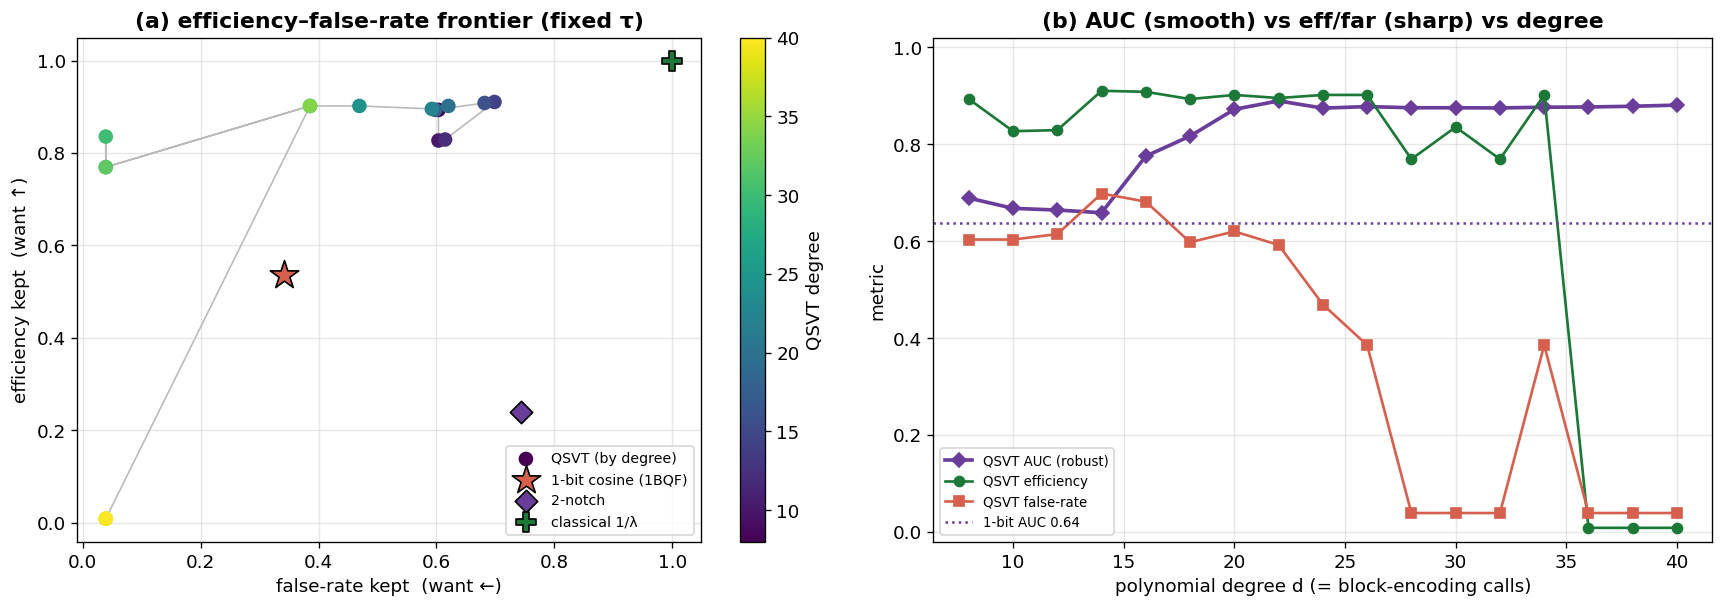

saved efficacy_frontier


In [3]:
def ef(g): r=Q.apply_filter(cl,g); return r["eff"],r["fp_kept"],r["auc"]
degs=np.arange(8,41,2); qe=[];qf=[];qa=[]
for d in degs:
    p=Q.design_keep_poly(d)
    if np.max(np.abs(p(np.linspace(0.7,6.7,2000))))>1.0: qe.append(np.nan);qf.append(np.nan);qa.append(np.nan); continue
    e,f,a=ef(lambda w,P=p:P(w)); qe.append(e);qf.append(f);qa.append(a)
qe,qf,qa=map(np.array,(qe,qf,qa))
e1,f1,a1=ef(Q.g_1bit); e2,f2,a2=ef(lambda w:Q.g_2notch(w,2.586)); ec,fc,ac=ef(Q.g_classical)
fig,ax=plt.subplots(1,2,figsize=(14.5,5.2))
sc=ax[0].scatter(qf,qe,c=degs,cmap="viridis",s=60,zorder=3,label="QSVT (by degree)")
ax[0].plot(qf,qe,'-',color="#bbb",lw=1,zorder=2)
ax[0].scatter([f1],[e1],marker="*",s=320,color="#d6604d",zorder=4,edgecolor="k",label="1-bit cosine (1BQF)")
ax[0].scatter([f2],[e2],marker="D",s=90,color="#6a3d9a",zorder=4,edgecolor="k",label="2-notch")
ax[0].scatter([fc],[ec],marker="P",s=140,color="#1b7837",zorder=4,edgecolor="k",label="classical 1/λ")
ax[0].set_xlabel("false-rate kept  (want ←)"); ax[0].set_ylabel("efficiency kept  (want ↑)")
ax[0].set_title("(a) efficiency–false-rate frontier (fixed τ)",fontweight="bold"); ax[0].legend(fontsize=8.5,loc="lower right")
plt.colorbar(sc,ax=ax[0],label="QSVT degree")
ax[1].plot(degs,qa,'D-',color="#6a3d9a",lw=2.2,label="QSVT AUC (robust)")
ax[1].plot(degs,qe,'o-',color="#1b7837",lw=1.6,label="QSVT efficiency")
ax[1].plot(degs,qf,'s-',color="#d6604d",lw=1.6,label="QSVT false-rate")
ax[1].axhline(a1,color="#6a3d9a",ls=":",lw=1.5,label=f"1-bit AUC {a1:.2f}")
ax[1].set_xlabel("polynomial degree d (= block-encoding calls)"); ax[1].set_ylabel("metric")
ax[1].set_title("(b) AUC (smooth) vs eff/far (sharp) vs degree",fontweight="bold"); ax[1].legend(fontsize=8); ax[1].set_ylim(-0.02,1.02)
fig.tight_layout()
for e,dp in (("pdf",600),("png",150)): fig.savefig(OUT/f"efficacy_frontier.{e}",dpi=dp,bbox_inches="tight",facecolor="white")
plt.show(); print("saved efficacy_frontier")

## 3. What it removes — hub vs bridge

In [4]:
def far_by_type(g):
    keep={"hub":[0,0],"bridge":[0,0]}; scale=Q.apply_filter(cl,g)["scale"]
    for c in cl:
        xq=np.abs(c["U"]@(c["beta"]*g(c["w"])))*scale; t=c["ftype"]
        for i in np.where(c["fp"])[0]:
            keep[t][1]+=1; keep[t][0]+= int(xq[i]>Q.TAU)
    return keep
for nm,g in [("1-bit cosine",Q.g_1bit),("QSVT deg 30",lambda w:pP(w))]:
    k=far_by_type(g)
    print(f"{nm:16s}: hub kept {k['hub'][0]}/{k['hub'][1]}  bridge kept {k['bridge'][0]}/{k['bridge'][1]}")

1-bit cosine    : hub kept 47/137  bridge kept 14/42
QSVT deg 30     : hub kept 7/137  bridge kept 0/42


## 4. Verdict (Step C)

- **QSVT strictly dominates the 1-bit filter.** The degree-30 band-limited inverse
  lifts the true/false **AUC from ~0.64 to ~0.88** and, at $\tau=0.35$, keeps **more**
  true tracks (0.84 vs 0.54) while passing far **fewer** false positives (0.04 vs
  0.34) — it nulls **all** off-length bridges and ~95% of the hubs.
- **Robust vs operating-point.** The AUC gain is robust (Step E); the specific eff/far
  at $\tau$ is knife-edge because true outer segments sit at $x\approx0.38\approx\tau$,
  so in practice one re-tunes $\tau$ (or weights the inverse to lift the outer
  segments). The *separation* is what improved.
- The residual is the spectrally-crowded remainder (m=3 hubs at 2.27, 0.11 below the
  true low mode) plus, at high density, the irreducible same-length $P_4$ bridges
  (Step A §4). A minimax/Lin–Tong design would push it lower at equal degree.
- **Cost:** degree $d$ = $d$ block-encoding calls — Step D.

**Answer to the original question: yes — a QSVT polynomial maps the hub and
off-length-bridge failure modes to ~0** (a strict, robust improvement over the 1-bit
notch), down to the same-length-bridge floor no spectral filter can cross.